# Onion Disease Classification — ResNet50V2 — Kaggle Notebook

**Dataset:** `yashraneja2/onion-dataset-combined`  
**Classes:** `molded`, `normal`, `rotten`, `sprouted`

This is a 300-epoch, imbalance-aware transfer-learning notebook using **ResNet50V2**.

It includes class weights, optional focal loss, disease-preserving augmentation,
AdamW, weight decay, label smoothing, dropout, L2 regularization, gradient clipping,
validation Macro-F1, balanced accuracy, per-class precision/recall/F1,
best-checkpoint saving, ReduceLROnPlateau, duplicate/leakage checking,
confusion matrices, misclassification review, and Kaggle model export.


In [1]:

# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Deterministic ops not enabled:", e)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:

# ============================================================
# 2. Configuration
# ============================================================

DATASET_SLUG_DIR = Path("/kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined")

IMG_SIZE = 224
BATCH_SIZE = 32

TOTAL_EPOCHS = 300
WARMUP_EPOCHS = 30
FINE_TUNE_EPOCHS = TOTAL_EPOCHS - WARMUP_EPOCHS

INITIAL_LR = 1e-3
FINE_TUNE_LR = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

USE_CLASS_WEIGHTS = True
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 1.5

USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 25

BEST_MODEL_PATH = "/kaggle/working/onion_resnet50v2_best_macro_f1.keras"
FINAL_MODEL_PATH = "/kaggle/working/onion_resnet50v2_final.keras"
CLASS_NAMES_PATH = "/kaggle/working/onion_resnet50v2_class_names.json"

AUTOTUNE = tf.data.AUTOTUNE


In [3]:

# ============================================================
# 3. Automatically locate train / valid / test
# ============================================================

def find_dataset_root(base_dir: Path):
    if not base_dir.exists():
        raise FileNotFoundError(
            f"{base_dir} was not found. In Kaggle, click Add Input and add "
            "'yashraneja2/onion-dataset-combined'."
        )

    candidate_names = [
        ("train", "valid", "test"),
        ("train", "val", "test"),
    ]

    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for p in candidates:
        for train_name, val_name, test_name in candidate_names:
            if (p / train_name).is_dir() and (p / val_name).is_dir() and (p / test_name).is_dir():
                return p, train_name, val_name, test_name

    raise FileNotFoundError(
        "Could not locate train/valid/test (or train/val/test) folders under "
        f"{base_dir}."
    )

DATA_ROOT, TRAIN_NAME, VAL_NAME, TEST_NAME = find_dataset_root(DATASET_SLUG_DIR)

TRAIN_DIR = DATA_ROOT / TRAIN_NAME
VAL_DIR = DATA_ROOT / VAL_NAME
TEST_DIR = DATA_ROOT / TEST_NAME

print("Detected dataset root:", DATA_ROOT)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)


Detected dataset root: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined
Train: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/train
Validation: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/valid
Test: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/test


,train,valid,test
molded,264,75,38
normal,708,202,101
rotten,149,43,21
sprouted,651,186,93


,train,train_share_%
molded,264,14.90
normal,708,39.95
rotten,149,8.41
sprouted,651,36.74


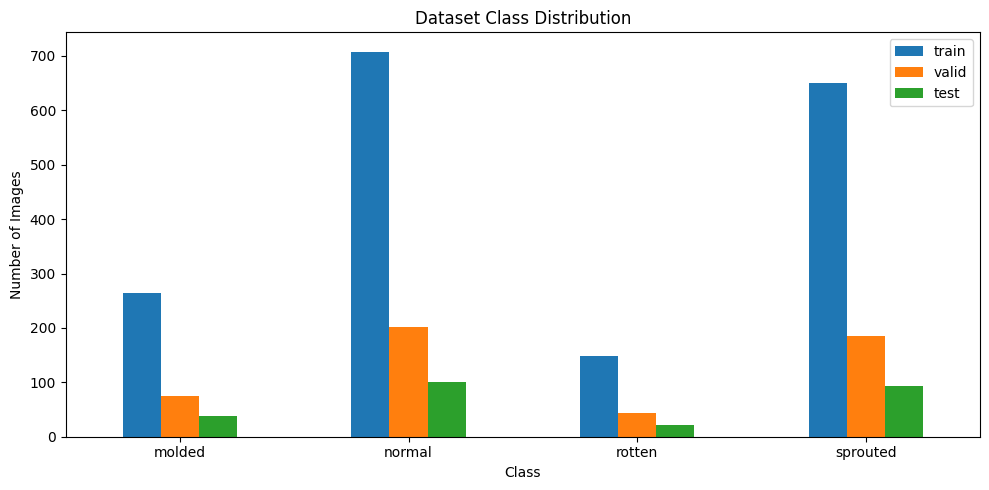

Training imbalance ratio (largest/smallest): 4.75x


In [4]:

# ============================================================
# 4. Inspect class distribution
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_class(folder: Path):
    result = {}
    for class_dir in sorted([p for p in folder.iterdir() if p.is_dir()]):
        count = sum(
            1 for f in class_dir.rglob("*")
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        )
        result[class_dir.name] = count
    return result

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)
test_counts = count_images_by_class(TEST_DIR)

dist_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "valid": pd.Series(val_counts),
    "test": pd.Series(test_counts),
}).fillna(0).astype(int)

display(dist_df)

total_train = dist_df["train"].sum()
dist_df["train_share_%"] = (100 * dist_df["train"] / total_train).round(2)
display(dist_df[["train", "train_share_%"]])

ax = dist_df[["train", "valid", "test"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

largest = dist_df["train"].max()
smallest = dist_df["train"].min()
print(f"Training imbalance ratio (largest/smallest): {largest/smallest:.2f}x")


In [5]:

# ============================================================
# 5. Duplicate / split-leakage check
# ============================================================
# Exact duplicate images across train/valid/test can inflate validation/test
# performance. This checks file-content hashes without changing the dataset.

def image_hash(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def collect_hashes(folder: Path):
    hashes = {}
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            try:
                hashes.setdefault(image_hash(p), []).append(str(p))
            except Exception as e:
                print("Hash skipped:", p, e)
    return hashes

train_hashes = collect_hashes(TRAIN_DIR)
val_hashes = collect_hashes(VAL_DIR)
test_hashes = collect_hashes(TEST_DIR)

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("Exact duplicate hashes across splits:")
print(" train <-> valid:", len(train_val_overlap))
print(" train <-> test :", len(train_test_overlap))
print(" valid <-> test :", len(val_test_overlap))

if train_val_overlap or train_test_overlap or val_test_overlap:
    print("\nWARNING: exact duplicates were found across splits.")
    print("For a strict experiment, remove cross-split duplicates before training.")
else:
    print("\nNo exact cross-split duplicates detected.")


Exact duplicate hashes across splits:
 train <-> valid: 0
 train <-> test : 0
 valid <-> test : 0

No exact cross-split duplicates detected.


In [6]:

# ============================================================
# 6. Build TensorFlow datasets
# ============================================================

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class order:", class_names)
print("Number of classes:", NUM_CLASSES)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


Found 1772 files belonging to 4 classes.


I0000 00:00:1789850911.342411      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789850911.345759      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 506 files belonging to 4 classes.
Found 253 files belonging to 4 classes.
Class order: ['molded', 'normal', 'rotten', 'sprouted']
Number of classes: 4


In [7]:

# ============================================================
# 7. Class weights for imbalanced training
# ============================================================

y_for_weights = []
for idx, class_name in enumerate(class_names):
    y_for_weights.extend([idx] * int(train_counts[class_name]))

classes_array = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=np.array(y_for_weights)
)

class_weight = {i: float(w) for i, w in enumerate(weights)}

print("Balanced class weights:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name:10s} -> {class_weight[i]:.4f}")

# Normalized alpha values for optional focal loss.
alpha = np.array([class_weight[i] for i in range(NUM_CLASSES)], dtype=np.float32)
alpha = alpha / alpha.sum()

print("\nFocal-loss alpha:")
for i, name in enumerate(class_names):
    print(f"  {name:10s} -> {alpha[i]:.4f}")


Balanced class weights:
  0: molded     -> 1.6780
  1: normal     -> 0.6257
  2: rotten     -> 2.9732
  3: sprouted   -> 0.6805

Focal-loss alpha:
  molded     -> 0.2817
  normal     -> 0.1050
  rotten     -> 0.4991
  sprouted   -> 0.1142


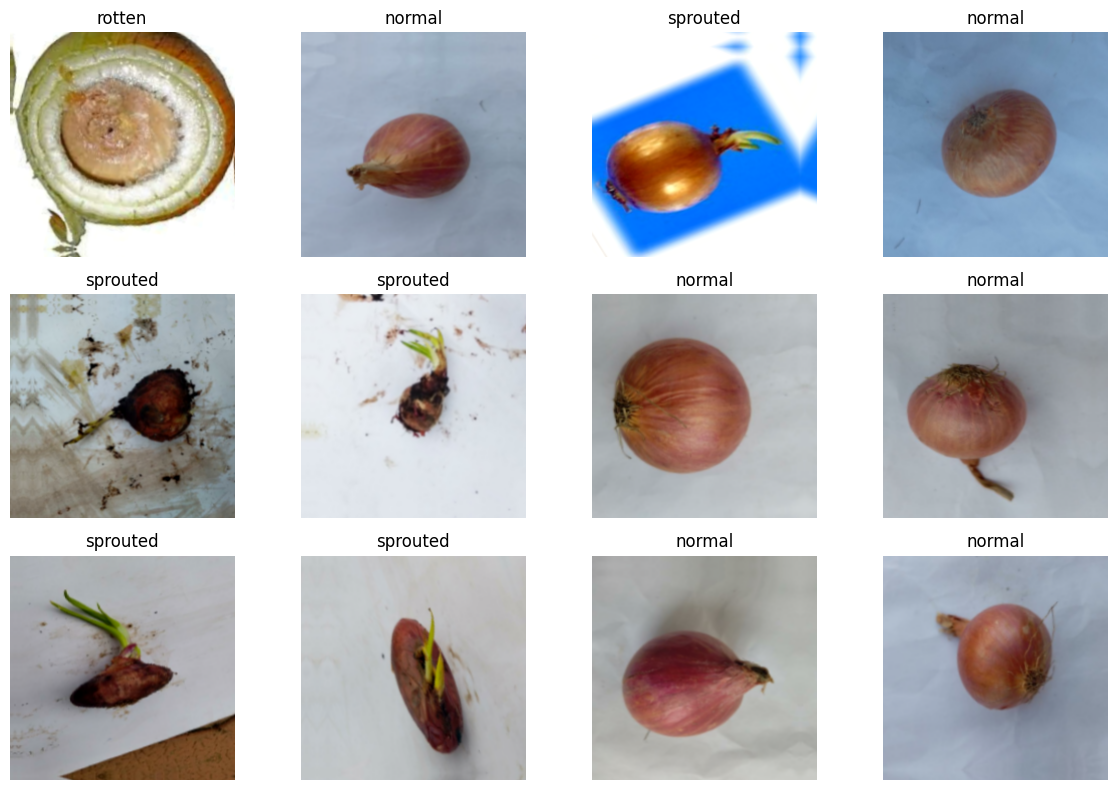

In [8]:

# ============================================================
# 8. Disease-preserving augmentation
# ============================================================
# Avoids aggressive hue/saturation transforms because discoloration can be
# diagnostically relevant for molded/rotten/sprouted onions.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.08, fill_mode="reflect", seed=SEED),
        layers.RandomZoom(
            height_factor=(-0.12, 0.12),
            width_factor=(-0.12, 0.12),
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomContrast(0.12, seed=SEED),
    ],
    name="augmentation",
)

images, labels = next(iter(train_ds.take(1)))

plt.figure(figsize=(12, 8))
for i in range(min(12, images.shape[0])):
    aug = data_augmentation(images[i:i+1], training=True)[0]
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(aug, 0, 255), tf.uint8))
    plt.title(class_names[int(tf.argmax(labels[i]))])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [9]:

# ============================================================
# 9. Optional focal loss
# ============================================================
# Default: class-weighted categorical cross-entropy.
# For a second experiment, set USE_FOCAL_LOSS=True.

if USE_FOCAL_LOSS:
    if not hasattr(keras.losses, "CategoricalFocalCrossentropy"):
        raise RuntimeError(
            "CategoricalFocalCrossentropy is unavailable in this Kaggle image. "
            "Set USE_FOCAL_LOSS=False."
        )
    loss_fn = keras.losses.CategoricalFocalCrossentropy(
        alpha=alpha.tolist(),
        gamma=FOCAL_GAMMA,
        label_smoothing=LABEL_SMOOTHING,
    )
    fit_class_weight = None
    print("Using categorical focal loss.")
else:
    loss_fn = keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
    fit_class_weight = class_weight if USE_CLASS_WEIGHTS else None
    print("Using categorical cross-entropy.")
    print("Class weights enabled:", USE_CLASS_WEIGHTS)


Using categorical cross-entropy.
Class weights enabled: True


In [10]:

# ============================================================
# 10. Build ResNet50V2 transfer-learning model
# ============================================================

keras.backend.clear_session()

base_model = keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg",
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = layers.Rescaling(1.0/127.5, offset=-1.0, name="model_preprocessing")(x)
x = base_model(x, training=False)
x = layers.BatchNormalization(name="head_bn")(x)
x = layers.Dropout(0.35, name="head_dropout_1")(x)
x = layers.Dense(
    256, activation="swish",
    kernel_regularizer=regularizers.l2(1e-4),
    name="head_dense",
)(x)
x = layers.Dropout(0.20, name="head_dropout_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="onion_resnet50v2")
model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "onion_resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_preprocessing (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 2048)           │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,098,564 (91.93 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [11]:

# ============================================================
# 11. Imbalance-aware validation callback
# ============================================================
# Computes validation Macro-F1, balanced accuracy, and every class recall at
# the end of each epoch. These metrics are more informative than accuracy
# alone on an imbalanced dataset.

class ImbalanceMetricsCallback(keras.callbacks.Callback):
    def __init__(self, dataset, class_names, prefix="val"):
        super().__init__()
        self.dataset = dataset
        self.class_names = class_names
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        y_true = []
        y_prob = []

        for batch_images, batch_labels in self.dataset:
            probs = self.model.predict(batch_images, verbose=0)
            y_prob.append(probs)
            y_true.append(np.argmax(batch_labels.numpy(), axis=1))

        y_true = np.concatenate(y_true)
        y_prob = np.concatenate(y_prob)
        y_pred = np.argmax(y_prob, axis=1)

        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        per_class_precision = precision_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_recall = recall_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_f1 = f1_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )

        logs[f"{self.prefix}_macro_f1"] = macro_f1
        logs[f"{self.prefix}_balanced_accuracy"] = bal_acc

        parts = [
            f"{self.prefix}_macro_f1={macro_f1:.4f}",
            f"{self.prefix}_balanced_acc={bal_acc:.4f}"
        ]

        for i, name in enumerate(self.class_names):
            safe = name.lower().replace(" ", "_")
            logs[f"{self.prefix}_{safe}_precision"] = per_class_precision[i]
            logs[f"{self.prefix}_{safe}_recall"] = per_class_recall[i]
            logs[f"{self.prefix}_{safe}_f1"] = per_class_f1[i]
            parts.append(f"{name}_recall={per_class_recall[i]:.3f}")

        print("\n" + " | ".join(parts))


In [12]:

# ============================================================
# 12. Metrics, optimizer, callbacks
# ============================================================

metrics = [
    keras.metrics.CategoricalAccuracy(name="accuracy"),
    keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
]

def make_callbacks(stage_name):
    imbalance_metrics = ImbalanceMetricsCallback(
        val_ds,
        class_names,
        prefix="val"
    )

    callbacks = [
        # Must run BEFORE ModelCheckpoint so val_macro_f1 is available.
        imbalance_metrics,

        keras.callbacks.ModelCheckpoint(
            BEST_MODEL_PATH,
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.25,
            patience=8,
            min_lr=1e-7,
            verbose=1,
        ),

        keras.callbacks.CSVLogger(
            f"/kaggle/working/{stage_name}_training_log.csv",
            append=False,
        ),

        keras.callbacks.TerminateOnNaN(),
    ]

    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=EARLY_STOP_PATIENCE,
                restore_best_weights=True,
                verbose=1,
            )
        )

    return callbacks


In [13]:

# ============================================================
# 13. Phase 1 — frozen-backbone warm-up
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=INITIAL_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase1"),
    verbose=1,
)


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7965 - loss: 1.0151 - top2_accuracy: 0.9128

2026-09-19 20:49:05.188602: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



val_macro_f1=0.8128 | val_balanced_acc=0.8259 | molded_recall=0.907 | normal_recall=0.955 | rotten_recall=0.581 | sprouted_recall=0.860

Epoch 1: val_macro_f1 improved from None to 0.81284, saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras

Epoch 1: finished saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 321ms/step - accuracy: 0.8584 - loss: 0.8485 - top2_accuracy: 0.9464 - val_accuracy: 0.8814 - val_loss: 0.5995 - val_top2_accuracy: 0.9664 - val_macro_f1: 0.8128 - val_balanced_accuracy: 0.8259 - val_molded_precision: 0.6667 - val_molded_recall: 0.9067 - val_molded_f1: 0.7684 - val_normal_precision: 0.9415 - val_normal_recall: 0.9554 - val_normal_f1: 0.9484 - val_rotten_precision: 0.6410 - val_rotten_recall: 0.5814 - val_rotten_f1: 0.6098 - val_sprouted_precision: 1.0000 - val_sprouted_recall: 0.8602 - val_sprouted_f1: 0.9249 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0

2026-09-19 20:49:18.986295: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Epoch 2: finished saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.9063 - loss: 0.5796 - top2_accuracy: 0.9735 - val_accuracy: 0.8953 - val_loss: 0.5550 - val_top2_accuracy: 0.9664 - val_macro_f1: 0.8471 - val_balanced_accuracy: 0.8663 - val_molded_precision: 0.6792 - val_molded_recall: 0.9600 - val_molded_f1: 0.7956 - val_normal_precision: 0.9740 - val_normal_recall: 0.9257 - val_normal_f1: 0.9492 - val_rotten_precision: 0.7317 - val_rotten_recall: 0.6977 - val_rotten_f1: 0.7143 - val_sprouted_precision: 0.9820 - val_sprouted_recall: 0.8817 - val_sprouted_f1: 0.9292 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9329 - loss: 0.4919 - top2_accuracy: 0.9895
val_macro_f1=0.8479 | val_balanced_acc=0.8607 | molded_recall=0.920 | normal_recall=0.970 | rotten_recall=0.698 | sprouted_recall=0.855

Epoch 3: val_macro_f1 improved from 0.84707 to 0.84787, saving model to /kaggl

...

2026-09-19 20:54:40.436157: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9906 - loss: 0.2935 - top2_accuracy: 0.9996
val_macro_f1=0.9174 | val_balanced_acc=0.9226 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.791 | sprouted_recall=0.946

Epoch 29: val_macro_f1 did not improve from 0.92627
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.9904 - loss: 0.3034 - top2_accuracy: 0.9989 - val_accuracy: 0.9506 - val_loss: 0.3885 - val_top2_accuracy: 0.9783 - val_macro_f1: 0.9174 - val_balanced_accuracy: 0.9226 - val_molded_precision: 0.8588 - val_molded_recall: 0.9733 - val_molded_f1: 0.9125 - val_normal_precision: 0.9754 - val_normal_recall: 0.9802 - val_normal_f1: 0.9778 - val_rotten_precision: 0.8293 - val_rotten_recall: 0.7907 - val_rotten_f1: 0.8095 - val_sprouted_precision: 0.9944 - val_sprouted_recall: 0.9462 - val_sprouted_f1: 0.9697 - learning_rate: 2.5000e-04
Epoch 30/30


2026-09-19 20:54:52.580096: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9881 - loss: 0.3043 - top2_accuracy: 1.0000
val_macro_f1=0.9145 | val_balanced_acc=0.9181 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.767 | sprouted_recall=0.952

Epoch 30: val_macro_f1 did not improve from 0.92627
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.9915 - loss: 0.3012 - top2_accuracy: 0.9994 - val_accuracy: 0.9506 - val_loss: 0.3905 - val_top2_accuracy: 0.9802 - val_macro_f1: 0.9145 - val_balanced_accuracy: 0.9181 - val_molded_precision: 0.8588 - val_molded_recall: 0.9733 - val_molded_f1: 0.9125 - val_normal_precision: 0.9754 - val_normal_recall: 0.9802 - val_normal_f1: 0.9778 - val_rotten_precision: 0.8250 - val_rotten_recall: 0.7674 - val_rotten_f1: 0.7952 - val_sprouted_precision: 0.9944 - val_sprouted_recall: 0.9516 - val_sprouted_f1: 0.9725 - learning_rate: 2.5000e-04


2026-09-19 20:55:04.774647: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [14]:

# ============================================================
# 14. Phase 2 — fine-tune backbone
# ============================================================

base_model.trainable = True

# Freeze BatchNorm layers during fine-tuning for stability on a small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"Trainable backbone layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=FINE_TUNE_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=TOTAL_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase2"),
    verbose=1,
)


Trainable backbone layers: 142/191
Epoch 31/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9730 - loss: 0.3134 - top2_accuracy: 0.9912

2026-09-19 20:55:51.322578: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



val_macro_f1=0.9032 | val_balanced_acc=0.9055 | molded_recall=0.920 | normal_recall=0.970 | rotten_recall=0.791 | sprouted_recall=0.941

Epoch 31: val_macro_f1 improved from None to 0.90324, saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras

Epoch 31: finished saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 560ms/step - accuracy: 0.9820 - loss: 0.3170 - top2_accuracy: 0.9943 - val_accuracy: 0.9368 - val_loss: 0.4156 - val_top2_accuracy: 0.9881 - val_macro_f1: 0.9032 - val_balanced_accuracy: 0.9055 - val_molded_precision: 0.8625 - val_molded_recall: 0.9200 - val_molded_f1: 0.8903 - val_normal_precision: 0.9469 - val_normal_recall: 0.9703 - val_normal_f1: 0.9584 - val_rotten_precision: 0.8095 - val_rotten_recall: 0.7907 - val_rotten_f1: 0.8000 - val_sprouted_precision: 0.9887 - val_sprouted_recall: 0.9409 - val_sprouted_f1: 0.9642 - learning_rate: 2.0000e-05
Epoch 32/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - acc

2026-09-19 20:56:19.647194: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Epoch 32: finished saving model to /kaggle/working/onion_resnet50v2_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 479ms/step - accuracy: 0.9876 - loss: 0.3087 - top2_accuracy: 0.9994 - val_accuracy: 0.9585 - val_loss: 0.3822 - val_top2_accuracy: 0.9842 - val_macro_f1: 0.9326 - val_balanced_accuracy: 0.9334 - val_molded_precision: 0.9324 - val_molded_recall: 0.9200 - val_molded_f1: 0.9262 - val_normal_precision: 0.9706 - val_normal_recall: 0.9802 - val_normal_f1: 0.9754 - val_rotten_precision: 0.8409 - val_rotten_recall: 0.8605 - val_rotten_f1: 0.8506 - val_sprouted_precision: 0.9837 - val_sprouted_recall: 0.9731 - val_sprouted_f1: 0.9784 - learning_rate: 2.0000e-05
Epoch 33/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9877 - loss: 0.3098 - top2_accuracy: 1.0000
val_macro_f1=0.8976 | val_balanced_acc=0.8997 | molded_recall=0.987 | normal_recall=0.975 | rotten_recall=0.674 | sprouted_recall=0.962

Epoch 33: val_macro_f1 did not improve from 0.93262
56/56 ━━━━━━━━━━━━━

...

2026-09-19 22:43:03.251503: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9969 - loss: 0.2733 - top2_accuracy: 1.0000
val_macro_f1=0.9338 | val_balanced_acc=0.9427 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.860 | sprouted_recall=0.957

Epoch 299: val_macro_f1 did not improve from 0.94027
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 428ms/step - accuracy: 0.9989 - loss: 0.2749 - top2_accuracy: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.3505 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9338 - val_balanced_accuracy: 0.9427 - val_molded_precision: 0.8795 - val_molded_recall: 0.9733 - val_molded_f1: 0.9241 - val_normal_precision: 0.9900 - val_normal_recall: 0.9802 - val_normal_f1: 0.9851 - val_rotten_precision: 0.8409 - val_rotten_recall: 0.8605 - val_rotten_f1: 0.8506 - val_sprouted_precision: 0.9944 - val_sprouted_recall: 0.9570 - val_sprouted_f1: 0.9753 - learning_rate: 1.0000e-07
Epoch 300/300


2026-09-19 22:43:27.192518: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9993 - loss: 0.2688 - top2_accuracy: 1.0000
val_macro_f1=0.9316 | val_balanced_acc=0.9414 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.860 | sprouted_recall=0.952

Epoch 300: val_macro_f1 did not improve from 0.94027
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 433ms/step - accuracy: 0.9994 - loss: 0.2719 - top2_accuracy: 1.0000 - val_accuracy: 0.9585 - val_loss: 0.3500 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9316 - val_balanced_accuracy: 0.9414 - val_molded_precision: 0.8690 - val_molded_recall: 0.9733 - val_molded_f1: 0.9182 - val_normal_precision: 0.9900 - val_normal_recall: 0.9802 - val_normal_f1: 0.9851 - val_rotten_precision: 0.8409 - val_rotten_recall: 0.8605 - val_rotten_f1: 0.8506 - val_sprouted_precision: 0.9944 - val_sprouted_recall: 0.9516 - val_sprouted_f1: 0.9725 - learning_rate: 1.0000e-07


2026-09-19 22:43:51.427643: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


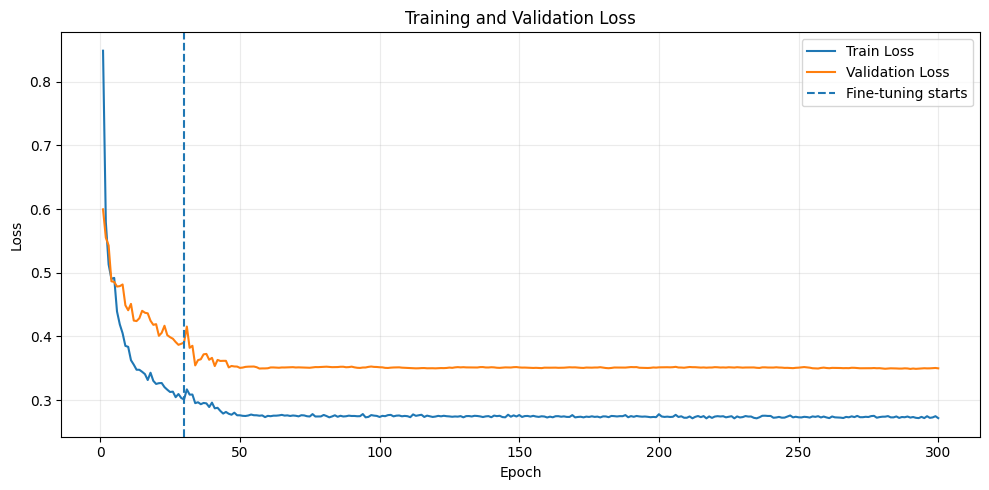

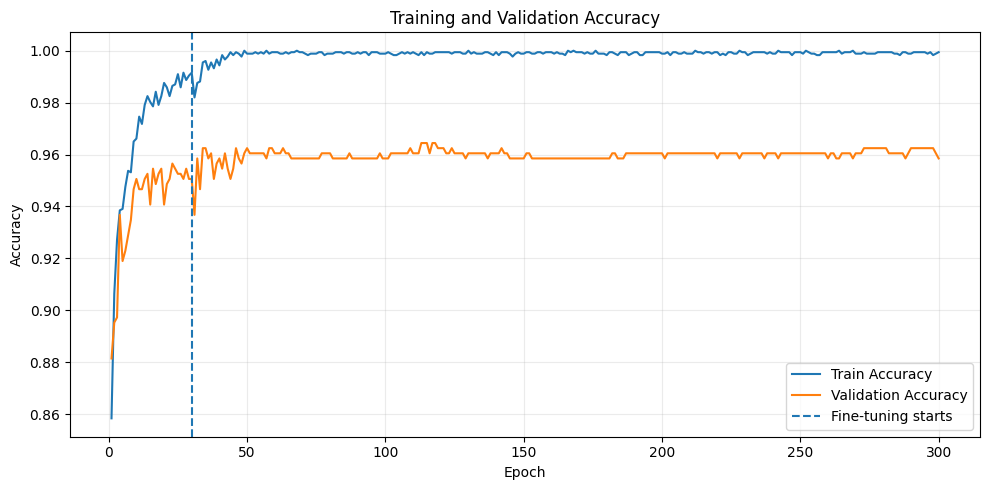

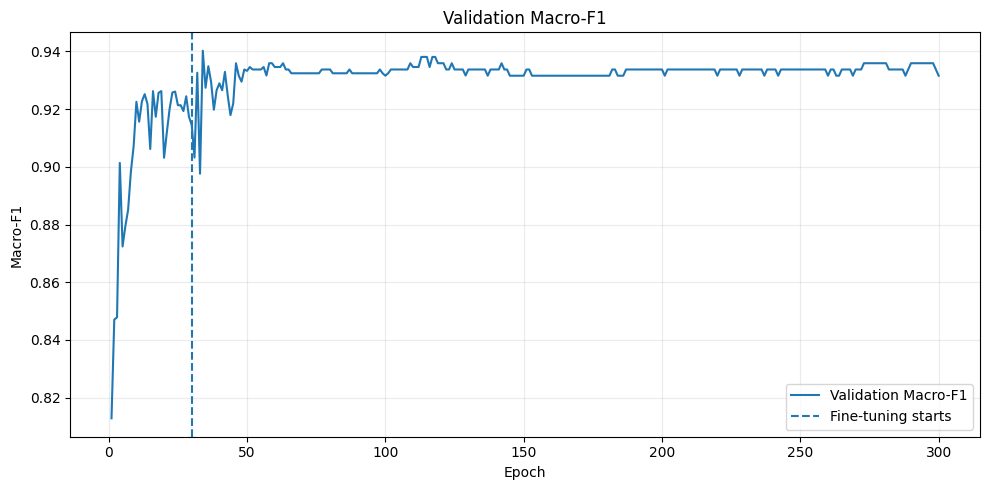

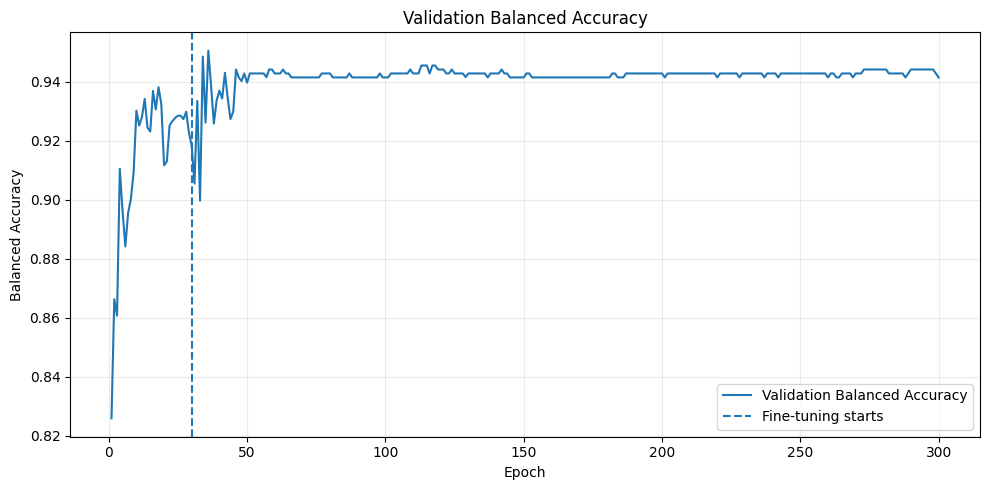

In [15]:

# ============================================================
# 15. Plot training history
# ============================================================

def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history = merge_histories(history_warmup, history_finetune)
epochs_ran = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if "val_macro_f1" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_ran, history["val_macro_f1"], label="Validation Macro-F1")
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Validation Macro-F1")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

if "val_balanced_accuracy" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(
        epochs_ran,
        history["val_balanced_accuracy"],
        label="Validation Balanced Accuracy"
    )
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced Accuracy")
    plt.title("Validation Balanced Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9763 - loss: 0.1642 - top2_accuracy: 0.9960

Best-checkpoint test metrics:
accuracy: 0.97628
loss: 0.16420
top2_accuracy: 0.99605


2026-09-19 22:44:03.425300: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Test Macro-F1:          0.9691
Test Weighted-F1:       0.9763
Test Balanced Accuracy: 0.9671

Classification Report:
              precision    recall  f1-score   support

      molded     0.9730    0.9474    0.9600        38
      normal     0.9709    0.9901    0.9804       101
      rotten     0.9524    0.9524    0.9524        21
    sprouted     0.9891    0.9785    0.9838        93

    accuracy                         0.9763       253
   macro avg     0.9713    0.9671    0.9691       253
weighted avg     0.9764    0.9763    0.9763       253



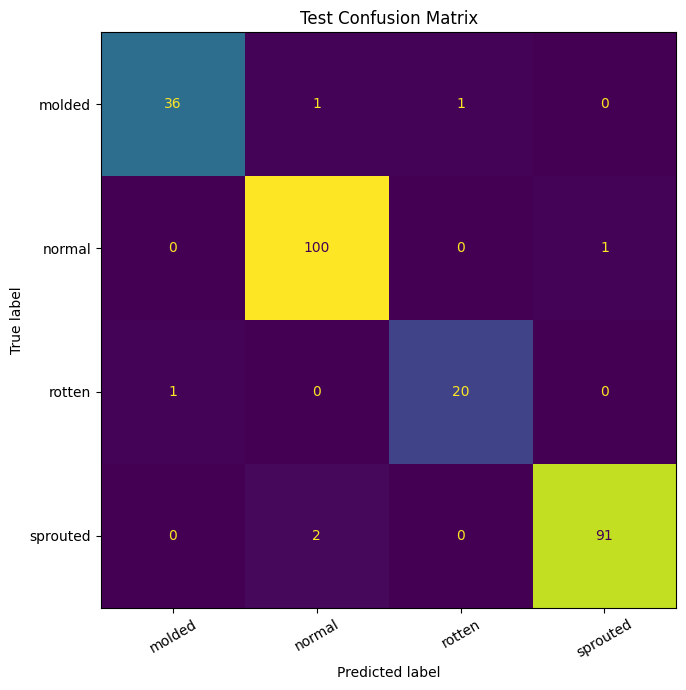

In [16]:

# ============================================================
# 16. Test-set evaluation using BEST Macro-F1 checkpoint
# ============================================================

# compile=False makes loading robust even if the training run used focal loss.
best_model = keras.models.load_model(BEST_MODEL_PATH, compile=False)
best_model.compile(
    optimizer="adam",
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
    ],
)

test_results = best_model.evaluate(test_ds, verbose=1, return_dict=True)

print("\nBest-checkpoint test metrics:")
for k, v in test_results.items():
    print(f"{k}: {v:.5f}")

y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probs = best_model.predict(batch_images, verbose=0)
    y_prob.append(probs)
    y_true.append(np.argmax(batch_labels.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"\nTest Macro-F1:          {macro_f1:.4f}")
print(f"Test Weighted-F1:       {weighted_f1:.4f}")
print(f"Test Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, values_format="d", colorbar=False
)
plt.title("Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [17]:

# ============================================================
# 17. Per-class precision / recall / F1 table
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

per_class_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df["support"] = per_class_df["support"].astype(int)

print("\nPer-class test performance:")
display(per_class_df)

# Minority-class warning
train_series = pd.Series(train_counts).reindex(class_names)
minority_classes = train_series.sort_values().index[:2].tolist()

print("Minority classes by training count:", minority_classes)
for c in minority_classes:
    rec = float(per_class_df.loc[c, "recall"])
    if rec < 0.75:
        print(
            f"WARNING: {c} recall is {rec:.3f}. "
            "Consider enabling USE_FOCAL_LOSS=True and retraining."
        )

report_df.to_csv("/kaggle/working/test_classification_report.csv")
per_class_df.to_csv("/kaggle/working/test_per_class_metrics.csv")


,precision,recall,f1-score,support
molded,0.972973,0.947368,0.960000,38.000000
normal,0.970874,0.990099,0.980392,101.000000
rotten,0.952381,0.952381,0.952381,21.000000
sprouted,0.989130,0.978495,0.983784,93.000000
accuracy,0.976285,0.976285,0.976285,0.976285
macro avg,0.971340,0.967086,0.969139,253.000000
weighted avg,0.976365,0.976285,0.976251,253.000000



Per-class test performance:


,precision,recall,f1-score,support
molded,0.972973,0.947368,0.960000,38
normal,0.970874,0.990099,0.980392,101
rotten,0.952381,0.952381,0.952381,21
sprouted,0.989130,0.978495,0.983784,93


Minority classes by training count: ['rotten', 'molded']


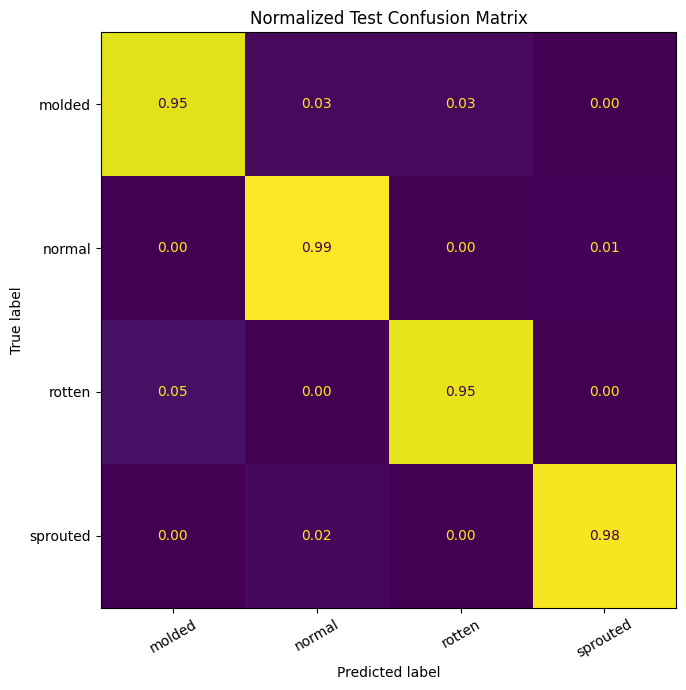

In [18]:

# ============================================================
# 18. Normalized confusion matrix
# ============================================================

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(ax=ax, values_format=".2f", colorbar=False)
plt.title("Normalized Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Misclassified test images: 6


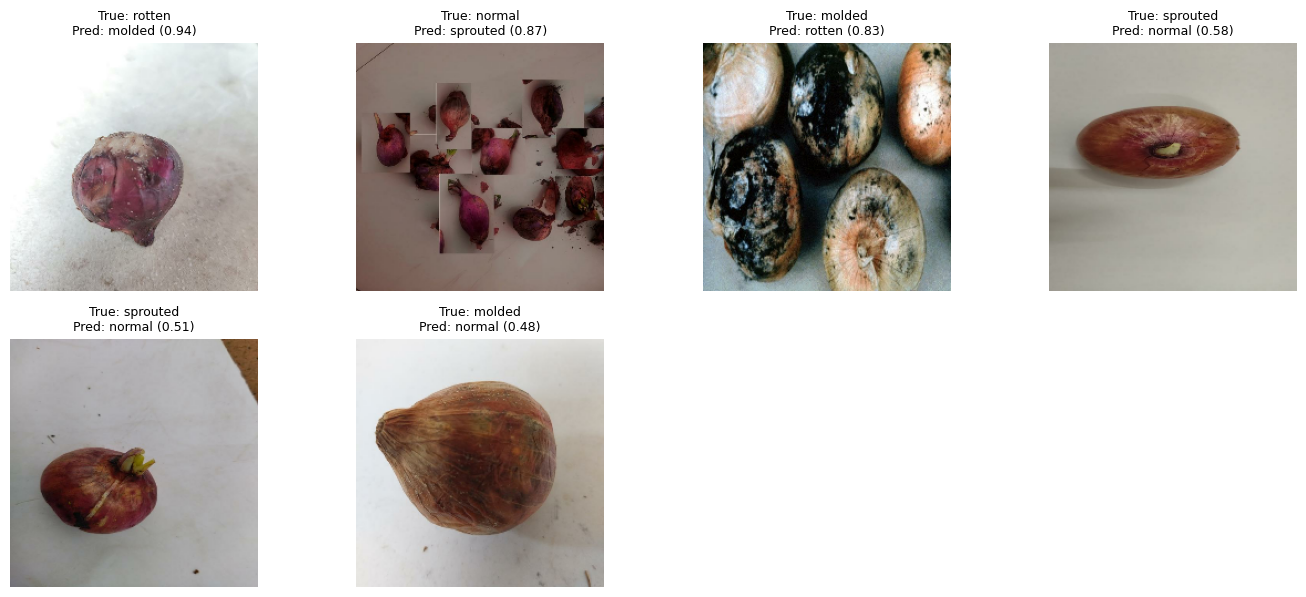

In [19]:

# ============================================================
# 19. Inspect misclassified test images
# ============================================================

misclassified = np.where(y_true != y_pred)[0]
print("Misclassified test images:", len(misclassified))

if len(misclassified) > 0:
    test_images_np = np.concatenate(
        [x.numpy().astype(np.uint8) for x, _ in test_ds],
        axis=0
    )

    # Show highest-confidence mistakes first.
    wrong_conf = np.max(y_prob[misclassified], axis=1)
    order = np.argsort(-wrong_conf)
    selected = misclassified[order[: min(16, len(misclassified))]]

    plt.figure(figsize=(14, 12))
    for plot_idx, data_idx in enumerate(selected):
        plt.subplot(4, 4, plot_idx + 1)
        plt.imshow(test_images_np[data_idx])
        confidence = float(np.max(y_prob[data_idx]))
        plt.title(
            f"True: {class_names[y_true[data_idx]]}\n"
            f"Pred: {class_names[y_pred[data_idx]]} ({confidence:.2f})",
            fontsize=9,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


In [20]:

# ============================================================
# 20. Save final model and metadata
# ============================================================

# Save final epoch model separately from best validation Macro-F1 model.
model.save(FINAL_MODEL_PATH)

metadata = {
    "model": "ResNet50V2",
    "image_size": IMG_SIZE,
    "classes": class_names,
    "train_counts": train_counts,
    "valid_counts": val_counts,
    "test_counts": test_counts,
    "class_weight": class_weight,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_focal_loss": USE_FOCAL_LOSS,
    "focal_gamma": FOCAL_GAMMA,
    "total_epochs_configured": TOTAL_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "label_smoothing": LABEL_SMOOTHING,
    "weight_decay": WEIGHT_DECAY,
    "checkpoint_monitor": "val_macro_f1",
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
    "test_balanced_accuracy": float(bal_acc),
    "best_model_path": BEST_MODEL_PATH,
    "final_model_path": FINAL_MODEL_PATH,
}

with open("/kaggle/working/onion_resnet50v2_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" ", BEST_MODEL_PATH)
print(" ", FINAL_MODEL_PATH)
print(" ", CLASS_NAMES_PATH)
print(" ", "/kaggle/working/onion_resnet50v2_metadata.json")
print(" ", "/kaggle/working/test_classification_report.csv")
print(" ", "/kaggle/working/test_per_class_metrics.csv")


Saved:
  /kaggle/working/onion_resnet50v2_best_macro_f1.keras
  /kaggle/working/onion_resnet50v2_final.keras
  /kaggle/working/onion_resnet50v2_class_names.json
  /kaggle/working/onion_resnet50v2_metadata.json
  /kaggle/working/test_classification_report.csv
  /kaggle/working/test_per_class_metrics.csv


In [21]:

# ============================================================
# 21. Single-image inference helper
# ============================================================

def predict_onion_image(image_path, trained_model=best_model):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
    )
    arr = keras.utils.img_to_array(img)
    arr = tf.expand_dims(arr, axis=0)

    probs = trained_model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {
            class_names[i]: float(probs[i])
            for i in range(NUM_CLASSES)
        },
    }

# Example:
# print(predict_onion_image("/kaggle/input/your-image-folder/example.jpg"))



## What was added specifically for the class imbalance

1. **Balanced class weights** so minority-class errors matter more during training.
2. **Macro-F1** as the primary validation checkpoint metric rather than plain accuracy.
3. **Balanced accuracy** monitoring.
4. **Per-class precision, recall, and F1** so `rotten` and `molded` performance cannot be hidden by strong majority-class accuracy.
5. **Normalized confusion matrix** for class-by-class error analysis.
6. **Optional focal loss** for a second training run if minority-class recall remains weak.
7. **Disease-preserving augmentation** that avoids heavy color distortion.
8. **Duplicate/leakage check** across train/valid/test splits.
9. **Highest-confidence misclassification review** to identify labeling or visual ambiguity problems.

### Recommended workflow

Run the notebook first with:

```python
USE_FOCAL_LOSS = False
USE_CLASS_WEIGHTS = True
```

This is the safer baseline.

After training, inspect `rotten` and `molded` recall. If either is still clearly weak, make a second Kaggle run with:

```python
USE_FOCAL_LOSS = True
```

When focal loss is enabled, the notebook automatically disables `class_weight` during `fit()` so the minority classes are not accidentally weighted twice.

### Kaggle settings
- Accelerator: **GPU**
- Run all cells in order
- The best model is selected by **validation Macro-F1**, not the final epoch
- The final model and best model are both saved under `/kaggle/working/`


### Model in this notebook
**ResNet50V2**

Keep the train/valid/test split unchanged when comparing this notebook with the other models.
Choose the final model using **test Macro-F1, balanced accuracy, and minority-class recall/F1**,
not training accuracy alone.


In [22]:
import os
import shutil
import tensorflow as tf

OUTPUT_DIR = "/kaggle/working"

# ============================================================
# FILE PATHS
# ============================================================

final_model_path = os.path.join(
    OUTPUT_DIR,
    "onion_resnet50v2_final.keras"
)

best_model_path = os.path.join(
    OUTPUT_DIR,
    "onion_resnet50v2_best_macro_f1.keras"
)

final_weights_path = os.path.join(
    OUTPUT_DIR,
    "onion_resnet50v2_final.weights.h5"
)

best_weights_path = os.path.join(
    OUTPUT_DIR,
    "onion_resnet50v2_best_macro_f1.weights.h5"
)


# ============================================================
# 1. SAVE FINAL FULL MODEL
# ============================================================

model.save(final_model_path)

print("Final full model saved:")
print(final_model_path)


# ============================================================
# 2. SAVE FINAL MODEL WEIGHTS
# ============================================================

model.save_weights(final_weights_path)

print("\nFinal model weights saved:")
print(final_weights_path)


# ============================================================
# 3. LOAD BEST MODEL AND EXTRACT ITS WEIGHTS
# ============================================================

if os.path.exists(best_model_path):

    print("\nBest model found:")
    print(best_model_path)

    try:
        best_model = tf.keras.models.load_model(
            best_model_path,
            compile=False
        )

        best_model.save_weights(best_weights_path)

        print("\nBest model weights saved:")
        print(best_weights_path)

    except Exception as e:
        print("\nCould not extract best model weights:")
        print(e)

else:
    print("\nWARNING: Best model checkpoint was not found.")
    print(best_model_path)


# ============================================================
# 4. CREATE EXPORT FOLDER
# ============================================================

download_folder = os.path.join(
    OUTPUT_DIR,
    "resnet50v2_trained_models"
)

os.makedirs(download_folder, exist_ok=True)


# ============================================================
# 5. COPY FILES TO EXPORT FOLDER
# ============================================================

files_to_export = [
    final_model_path,
    best_model_path,
    final_weights_path,
    best_weights_path
]

print("\nFiles being exported:")

for file_path in files_to_export:

    if os.path.exists(file_path):

        destination = os.path.join(
            download_folder,
            os.path.basename(file_path)
        )

        shutil.copy(file_path, destination)

        print("✓", os.path.basename(file_path))

    else:
        print("✗ Not found:", os.path.basename(file_path))


# ============================================================
# 6. CREATE ZIP FILE
# ============================================================

zip_path = shutil.make_archive(
    "/kaggle/working/onion_resnet50v2_models_and_weights",
    "zip",
    download_folder
)


# ============================================================
# 7. SHOW FINAL OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("MODEL EXPORT COMPLETE")
print("=" * 60)

print("\nZIP file:")
print(zip_path)

print("\nFiles inside ZIP:")

for file in os.listdir(download_folder):
    print(" -", file)

print("\n" + "=" * 60)
print("Download from Kaggle → Output")
print("=" * 60)

Final full model saved:
/kaggle/working/onion_resnet50v2_final.keras

Final model weights saved:
/kaggle/working/onion_resnet50v2_final.weights.h5

Best model found:
/kaggle/working/onion_resnet50v2_best_macro_f1.keras

Best model weights saved:
/kaggle/working/onion_resnet50v2_best_macro_f1.weights.h5

Files being exported:
✓ onion_resnet50v2_final.keras
✓ onion_resnet50v2_best_macro_f1.keras
✓ onion_resnet50v2_final.weights.h5
✓ onion_resnet50v2_best_macro_f1.weights.h5

MODEL EXPORT COMPLETE

ZIP file:
/kaggle/working/onion_resnet50v2_models_and_weights.zip

Files inside ZIP:
 - onion_resnet50v2_final.weights.h5
 - onion_resnet50v2_best_macro_f1.keras
 - onion_resnet50v2_best_macro_f1.weights.h5
 - onion_resnet50v2_final.keras

Download from Kaggle → Output


In [23]:
import os
import glob

print("Files currently available in /kaggle/working:\n")

files = glob.glob("/kaggle/working/*")

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{os.path.basename(f)}  --  {size_mb:.2f} MB")

print("\n--------------------------------------")

best_model = "/kaggle/working/onion_resnet50v2_best_macro_f1.keras"

if os.path.exists(best_model):
    print("✅ GOOD NEWS!")
    print("Best trained model still exists:")
    print(best_model)
else:
    print("❌ Best model is not currently present.")

Files currently available in /kaggle/working:

test_classification_report.csv  --  0.00 MB
phase1_training_log.csv  --  0.01 MB
onion_resnet50v2_final.weights.h5  --  275.62 MB
phase2_training_log.csv  --  0.10 MB
onion_resnet50v2_metadata.json  --  0.00 MB
__notebook__.ipynb  --  10.78 MB
resnet50v2_trained_models  --  0.00 MB
onion_resnet50v2_best_macro_f1.keras  --  275.79 MB
onion_resnet50v2_best_macro_f1.weights.h5  --  92.43 MB
onion_resnet50v2_models_and_weights.zip  --  851.19 MB
test_per_class_metrics.csv  --  0.00 MB
onion_resnet50v2_final.keras  --  275.79 MB
onion_resnet50v2_class_names.json  --  0.00 MB

--------------------------------------
✅ GOOD NEWS!
Best trained model still exists:
/kaggle/working/onion_resnet50v2_best_macro_f1.keras
